## Goals: Feature Engineering

This notebook merge *Brazil* and *France* dataset into a single training dataset.
It adds seasonal information (seasons, month), scale relevent features and removed unecessary columns.

> Note this notebook need ouputs from both *01a - Data Preprocessing Brazil* and 01b - *Data Preprocessing France*

![Alt text](../images/notebook-2.png)

### 1. Data Import and Setup

Imports necessary libraries, sets up environment paths, and includes custom utility functions.



In [80]:
import sys
import os
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, StandardScaler
from sklearn.pipeline import Pipeline

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(BASE_DIR)

from src.utils.plots import plot_water_flows

Defines constants :
* INPUT_DIR must be the same as the one defined in *01 - Data Preprocessing* notebook.
* EVAL_DIR must be the same as the one defined in *01 - Data Preprocessing* notebook.

In [81]:
INPUT_DIR = "../../../data/input/"
EVAL_DIR = "../../../data/evaluation/"

datasets = { "train": INPUT_DIR, "eval" : EVAL_DIR}


### 2. Data Loading and Initial Cleaning

* Reads in the French and Brazilian baseline datasets, removes unnecessary columns, and sets the date as the index.
* Introduces a binary indicator (`north_hemisphere`) to distinguish between data from France and Brazil.
* Merges the French and Brazilian datasets into a single DataFrame for further processing.

In [82]:
dataset_baseline = {}

for set, dir in datasets.items():
    path_data_baseline_france = f"{dir}preprocessed_france.csv"
    dataset_baseline_france = pd.read_csv(path_data_baseline_france)

    dataset_baseline_france = dataset_baseline_france.iloc[:,1:]
    dataset_baseline_france = dataset_baseline_france.drop(columns=["index"])


    dataset_baseline_france = (
        dataset_baseline_france
        .set_index("ObsDate")
    )

    path_data_baseline = f"{dir}preprocessed_brazil.csv"
    dataset_baseline_brazil = pd.read_csv(path_data_baseline)

    # remove the first column
    dataset_baseline_brazil = dataset_baseline_brazil.iloc[:,1:]
    dataset_baseline_brazil = dataset_baseline_brazil.drop(columns=["index"])

    dataset_baseline_brazil = (
        dataset_baseline_brazil
        .set_index("ObsDate")
    )


    dataset_baseline_france["north_hemisphere"] = 1
    dataset_baseline_brazil["north_hemisphere"] = 0

    dataset_baseline[set] = pd.concat([dataset_baseline_france, dataset_baseline_brazil], axis=0)

### 3. Feature Engineering

Creates seasonal and monthly indicator columns.


In [83]:
for set, dir in datasets.items():
    # Convert the index to datetime and extract the month
    month = pd.to_datetime(dataset_baseline[set].index).month

    # Define season mappings
    seasons = {
        "is_winter": [1, 2, 3],
        "is_spring": [4, 5, 6],
        "is_summer": [7, 8, 9],
        "is_autumn": [10, 11, 12],
    }

    # Apply season flags
    for season, months in seasons.items():
        dataset_baseline[set][season] = month.isin(months)

    # Define month abbreviations and apply monthly flags
    months_abbr = ["jan", "feb", "mar", "apr", "may", "jun",
                "jul", "aug", "sep", "oct", "nov", "dec"]
    for i, abbr in enumerate(months_abbr, start=1):
        dataset_baseline[set][f"is_{abbr}"] = month == i

Applies MaxAbs scaling to the selected features.

In [84]:
for set, dir in datasets.items():
    scaler = MaxAbsScaler()
    cols = dataset_baseline[set].columns
    # remove the water_flows columns
    if set == "eval":
        cols = cols.drop(["station_code", "water_flow_lag_1w", "water_flow_lag_2w"])
    elif set == "train":
        cols = cols.drop(["water_flow_week1", "station_code", "water_flow_week2", "water_flow_week3", "water_flow_week4", "water_flow_lag_1w"])
    dataset_baseline[set][cols] = scaler.fit_transform(dataset_baseline[set][cols])

### 4. Handling Missing Data

Removes undesired columns, identifies columns with missing values, and imputes them with their respective column means.


In [85]:
# remove columns that start with index_
for set, dir in datasets.items():
    cols = dataset_baseline[set].columns
    cols = cols[~cols.str.startswith("index_")]
    dataset_baseline[set] = dataset_baseline[set][cols]

    # find columns that contains nan values

    cols_nan = dataset_baseline[set].columns[dataset_baseline[set].isna().any()].tolist()

    # impute nan values with the mean
    for col in cols_nan:
        dataset_baseline[set][col] = dataset_baseline[set][col].fillna(dataset_baseline[set][col].mean())

### 4.1 Adding SnowIndex


In [86]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class SnowIndexComputeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, altitude_weight=0.5, temp_weight=0.3, precip_weight=0.7):
        self.altitude_weight = altitude_weight
        self.temp_weight = temp_weight
        self.precip_weight = precip_weight

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        required_columns = ['altitude', 'temperatures', 'precipitations']
        if not all(col in X.columns for col in required_columns):
            raise ValueError(f"Le DataFrame doit contenir les colonnes : {required_columns}")
        
        snow_index = (
            (X['altitude'] * self.altitude_weight) *
            (X['precipitations'] * self.precip_weight) /
            (X['temperatures'] * self.temp_weight)
        )
        
        snow_index.replace([np.inf, -np.inf], np.nan, inplace=True)
        snow_index.fillna(0, inplace=True)
        
        # Normaliser le SnowIndex entre 0 et 1
        snow_index = (snow_index - snow_index.min()) / (snow_index.max() - snow_index.min())
        
        X_transformed = X.copy()
        X_transformed['snow_index'] = snow_index
        
        return X_transformed

In [87]:
transformer = SnowIndexComputeTransformer()
dataset_baseline["train"] = transformer.fit_transform(dataset_baseline["train"])
dataset_baseline["eval"] = transformer.fit_transform(dataset_baseline["eval"])
print(dataset_baseline["train"]["snow_index"].min())
print(dataset_baseline["train"]["snow_index"].max())
print(dataset_baseline["train"]["snow_index"])

0.0
1.0
ObsDate
1990-01-21    0.015069
1990-01-28    0.052493
1990-02-04    0.018335
1990-02-11    0.021359
1990-02-18    0.095575
                ...   
2003-12-07    0.012682
2003-12-14    0.000909
2003-12-21    0.001407
2003-12-28    0.014559
2004-01-04    0.006409
Name: snow_index, Length: 28431, dtype: float64


In [88]:
print(dataset_baseline["train"].shape)
print(dataset_baseline["eval"].shape)

(28431, 160)
(1352, 156)


### 4.2 Executing PCA strategy on soil composition

In [89]:
from sklearn.decomposition import PCA

# Sélection des colonnes pertinentes
keys_to_select = [
    f"{var}_{depth}_mean_index__region"
    for var in ["sand", "bdod", "cfvo", "clay"]
    for depth in ["0-5cm", "5-15cm", "15-30cm", "30-60cm", "60-100cm", "100-200cm"]
]

# Appliquer le PCA
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(dataset_baseline["train"][keys_to_select])
X_eval_pca = pca.fit_transform(dataset_baseline["eval"][keys_to_select])


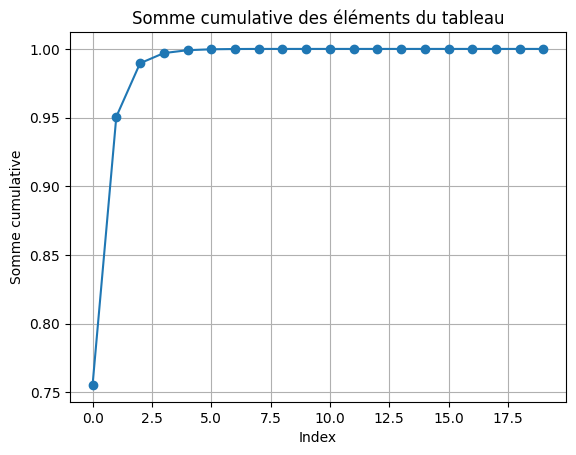

In [90]:
import matplotlib.pyplot as plt

def cumulative_sum(arr):
    result = []
    current_sum = 0
    for num in arr:
        current_sum += num
        result.append(current_sum)
    return result

cumulative_sums = cumulative_sum(pca.explained_variance_ratio_)

plt.plot(cumulative_sums, marker='o')
plt.title('Somme cumulative des éléments du tableau')
plt.xlabel('Index')
plt.ylabel('Somme cumulative')
plt.grid(True)
plt.show()


Seems that only 4 pcas are necessary to express the complete complexity of soil composition

In [ ]:
principalTrainDf = pd.DataFrame(data=X_train_pca[:, :4], columns=['soil_pca_1', 'soil_pca_2', 'soil_pca_3', 'soil_pca_4'])
principalEvalDf = pd.DataFrame(data=X_eval_pca[:, :4], columns=['soil_pca_1', 'soil_pca_2', 'soil_pca_3', 'soil_pca_4'])

# Ensure the index is unique before concatenation
dataset_baseline["train"] = dataset_baseline["train"].reset_index(drop=False)
dataset_baseline["eval"] = dataset_baseline["eval"].reset_index(drop=False)
principalTrainDf = principalTrainDf.reset_index(drop=False)
principalEvalDf = principalEvalDf.reset_index(drop=False)

# Concatenate the dataframes along the columns
dataset_baseline["train"] = pd.concat([dataset_baseline["train"], principalTrainDf], axis=1)
dataset_baseline["eval"] = pd.concat([dataset_baseline["eval"], principalEvalDf], axis=1)

print(dataset_baseline["train"].shape)
print(dataset_baseline["eval"].shape)

(28431, 164)
(1352, 160)


In [92]:
# Keeping only 4 first pcas and deleting previous values
dataset_baseline["train"] = dataset_baseline["train"].drop(columns=keys_to_select)
dataset_baseline["eval"] = dataset_baseline["eval"].drop(columns=keys_to_select)
print(dataset_baseline["train"].shape)
print(dataset_baseline["eval"].shape)

(28431, 140)
(1352, 136)


### 5. Data Saving, and Visualization

Saves the complete baseline.

In [93]:
for set, dir in datasets.items():
    dataset_baseline[set].to_csv(f"{dir}dataset_custom_baseline.csv")